# PCA

**Task 1: Exploratory Data Analysis (EDA)**

In [ ]:
##importing libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.cluster import KMeans

from sklearn.metrics import silhouette_score
from sklearn.metrics import davies_bouldin_score

In [ ]:
df = pd.read_csv("wine.csv")

df.head()

,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [ ]:
df.shape

(178, 14)

In [ ]:
df.describe()

,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,1.938202,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.775035,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,1.000000,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,1.000000,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,2.000000,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,3.000000,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,3.000000,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Type             178 non-null    int64  
 1   Alcohol          178 non-null    float64
 2   Malic            178 non-null    float64
 3   Ash              178 non-null    float64
 4   Alcalinity       178 non-null    float64
 5   Magnesium        178 non-null    int64  
 6   Phenols          178 non-null    float64
 7   Flavanoids       178 non-null    float64
 8   Nonflavanoids    178 non-null    float64
 9   Proanthocyanins  178 non-null    float64
 10  Color            178 non-null    float64
 11  Hue              178 non-null    float64
 12  Dilution         178 non-null    float64
 13  Proline          178 non-null    int64  
dtypes: float64(11), int64(3)
memory usage: 19.6 KB


In [ ]:
df.isnull().sum()

,0
Type,0
Alcohol,0
Malic,0
Ash,0
Alcalinity,0
Magnesium,0
Phenols,0
Flavanoids,0
Nonflavanoids,0
Proanthocyanins,0


In [ ]:
df.duplicated().sum()

np.int64(0)

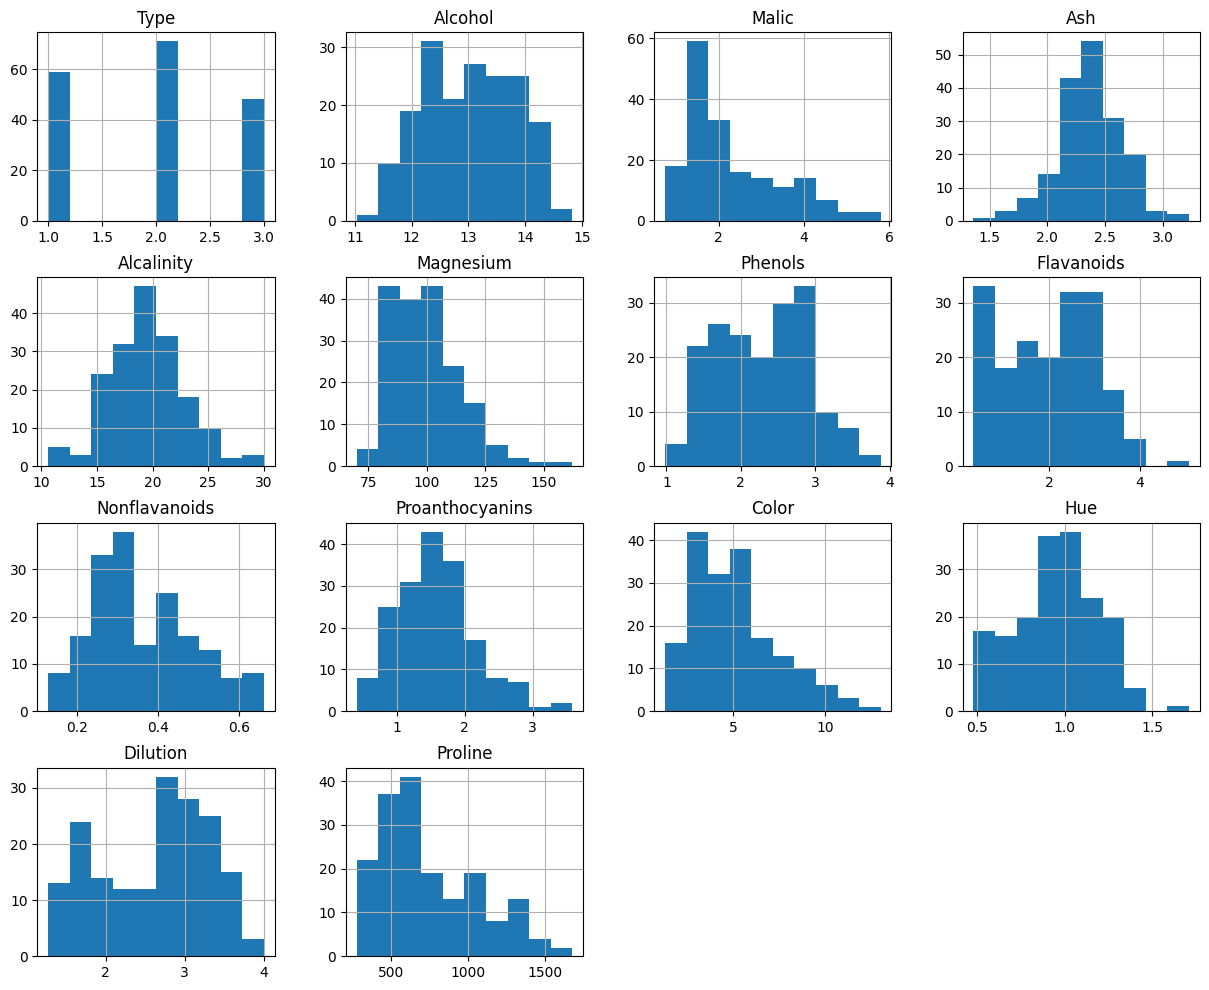

In [ ]:
#histogram
df.hist(figsize=(15,12))

plt.show()

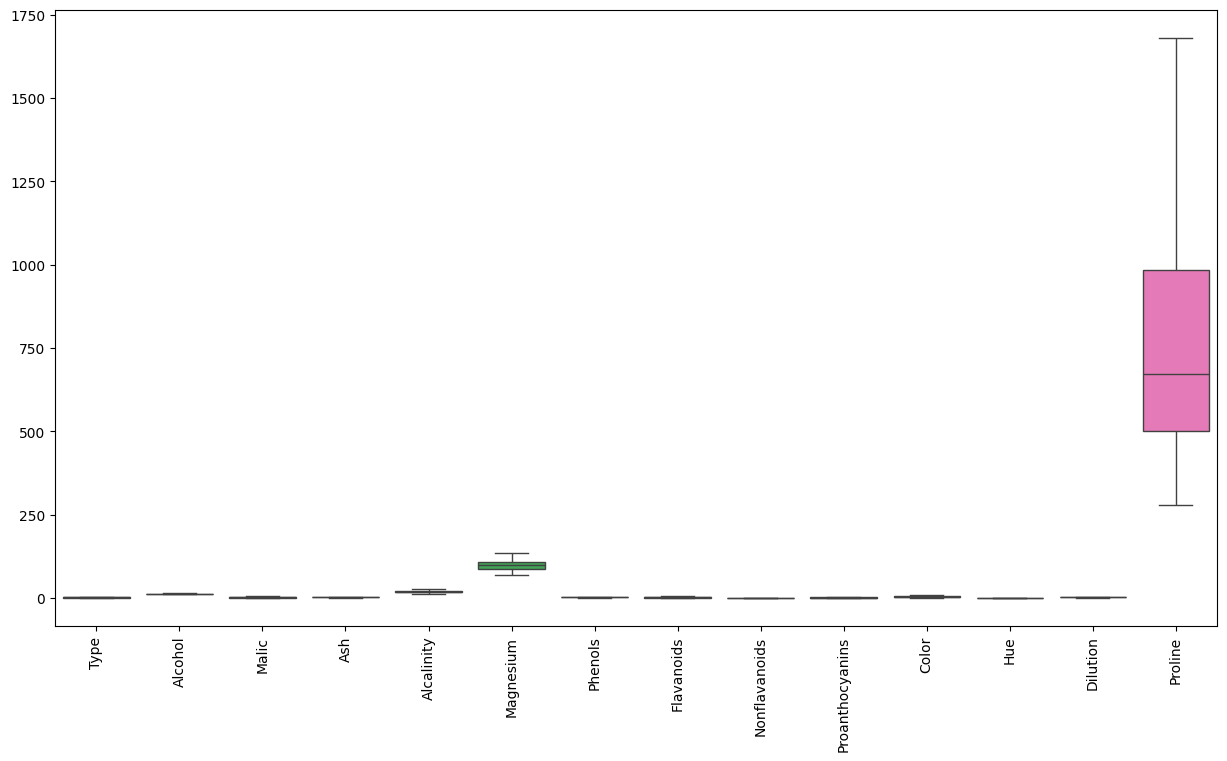

<Axes: >

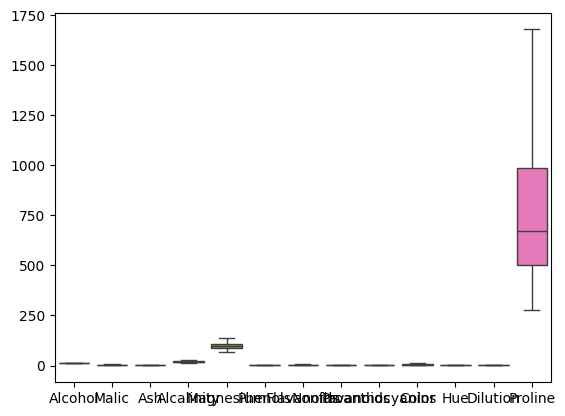

In [ ]:
#boxplot
plt.figure(figsize=(15,8))

sns.boxplot(data=df)

plt.xticks(rotation=90)

plt.show()
sns.boxplot(data=df.drop(columns=['Type']))

In [ ]:
#outlier capping
def outlier_capping(df,column):
    Q1= df[column].quantile(0.25)
    Q3= df[column].quantile(0.75)
    IQR= Q3-Q1
    lower_extreme= Q1-1.5*IQR
    upper_extreme= Q3+1.5*IQR
    df[column]= df[column].apply(lambda x:lower_extreme if x<lower_extreme else upper_extreme if x>upper_extreme else x )
for col in df.select_dtypes(include=['int','float']).columns:
    outlier_capping(df,col)

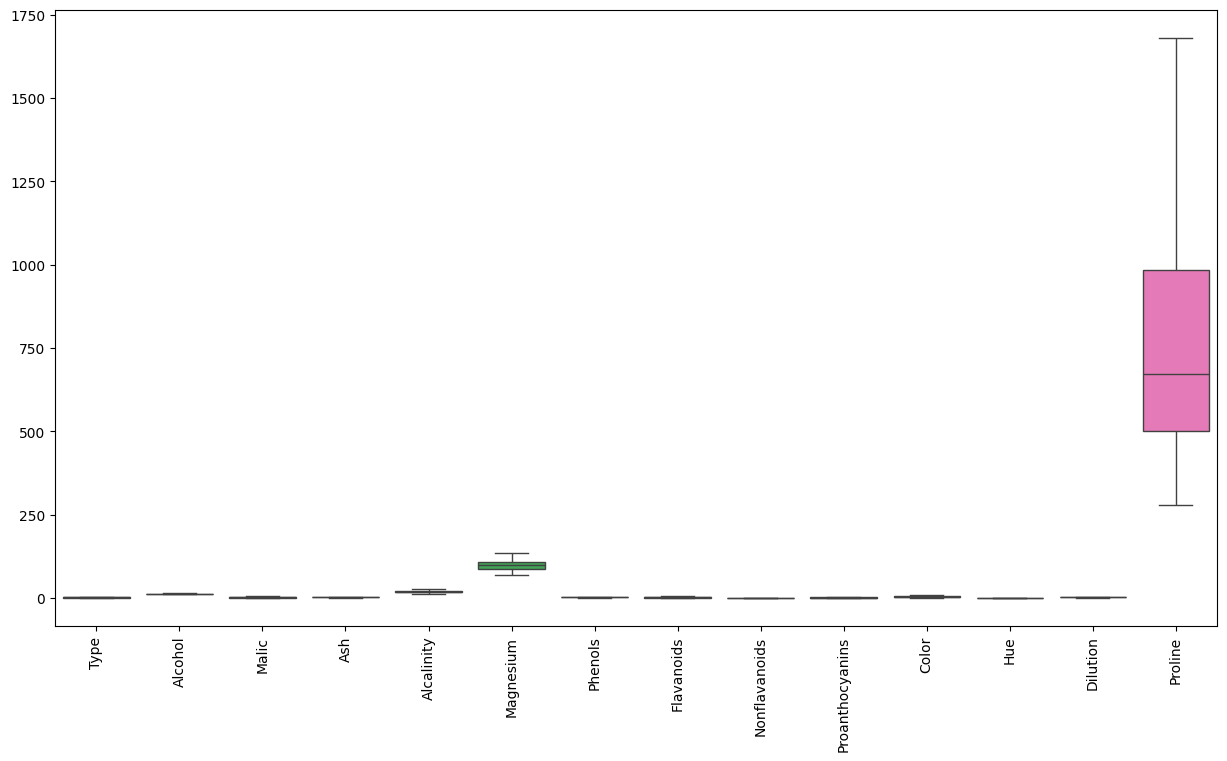

In [ ]:
plt.figure(figsize=(15,8))

sns.boxplot(data=df)

plt.xticks(rotation=90)

plt.show()

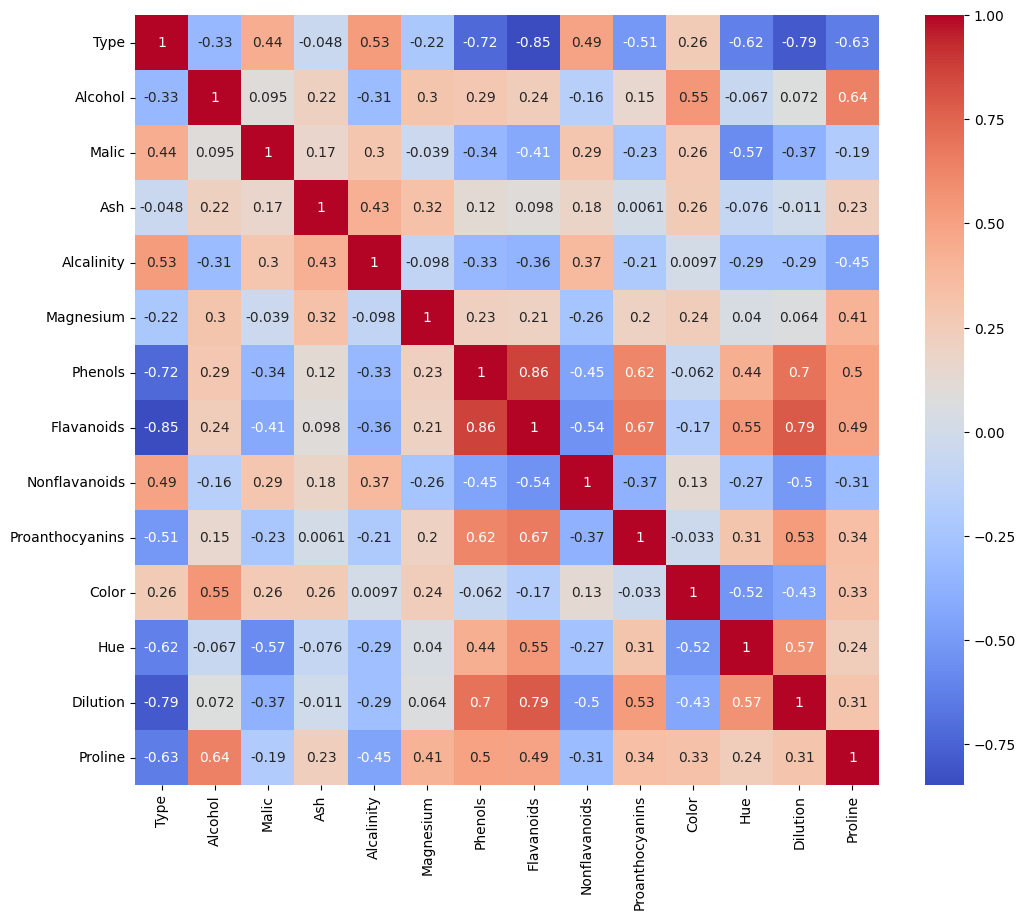

In [ ]:
#Correlation Heatmap
plt.figure(figsize=(12,10))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.show()

**Task 2: Dimensionality Reduction with PCA**


In [ ]:
#Select Features
X = df.drop("Type",axis=1)

In [ ]:
#Standardize Data
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [ ]:
#applying pca
pca = PCA()

X_pca = pca.fit_transform(X_scaled)

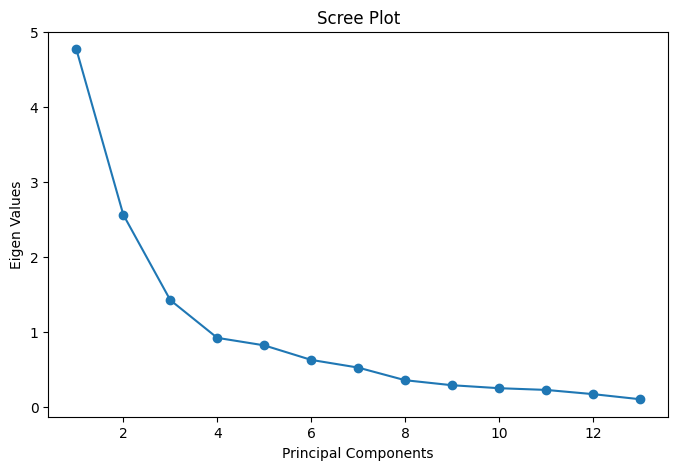

In [ ]:
#Scree Plot
plt.figure(figsize=(8,5))

plt.plot(
    range(1,len(pca.explained_variance_)+1),
    pca.explained_variance_,
    marker='o'
)

plt.xlabel("Principal Components")

plt.ylabel("Eigen Values")

plt.title("Scree Plot")

plt.show()

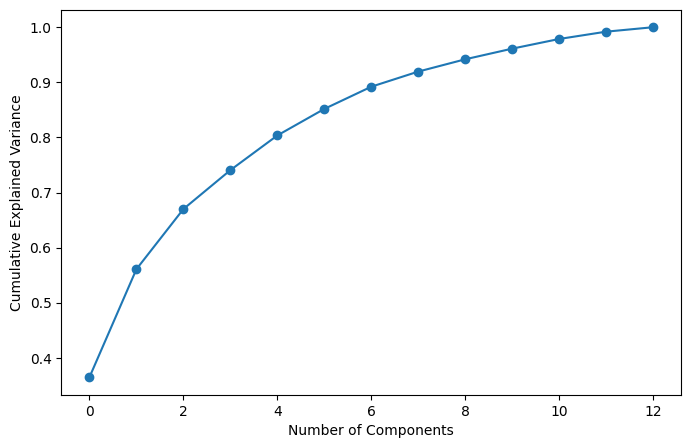

In [ ]:
#Cumulative Explained Variance
plt.figure(figsize=(8,5))

plt.plot(
    np.cumsum(pca.explained_variance_ratio_),
    marker='o'
)

plt.xlabel("Number of Components")

plt.ylabel("Cumulative Explained Variance")

plt.show()

In [ ]:
#Choose Principal Components
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

**Task 3: Clustering with Original Data**

In [ ]:
# Appling KMeans
kmeans_original = KMeans(
    n_clusters=3,
    random_state=42
)

original_clusters = kmeans_original.fit_predict(X_scaled)

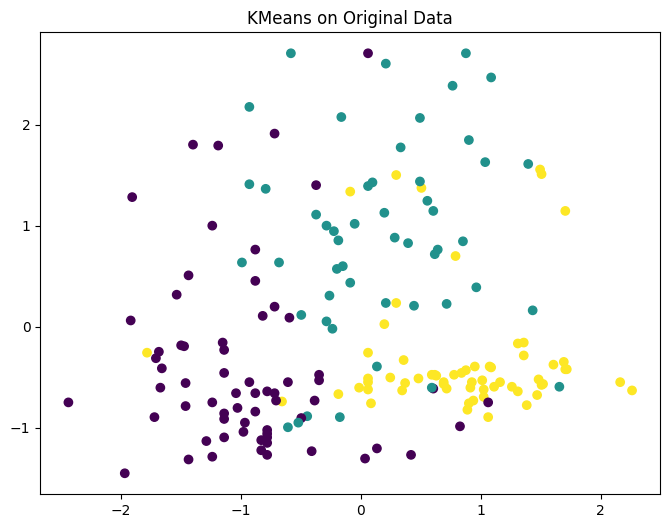

In [ ]:
#visualizing clusters
plt.figure(figsize=(8,6))

plt.scatter(
    X_scaled[:,0],
    X_scaled[:,1],
    c=original_clusters,
    cmap="viridis"
)

plt.title("KMeans on Original Data")

plt.show()

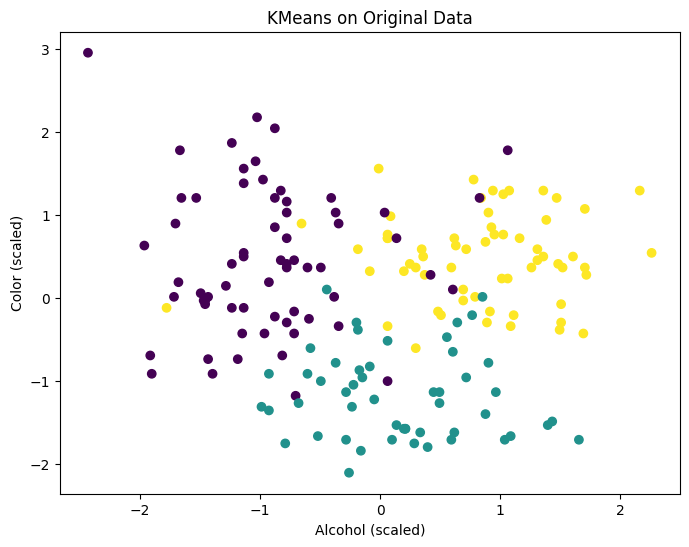

In [ ]:
# Scatter plot for clusters on original data (using Alcohol vs Color as example)
plt.figure(figsize=(8,6))
plt.scatter(
    X_scaled[:, 0],   # Alcohol (first feature)
    X_scaled[:, 10],  # Color (11th feature)
    c=original_clusters,
    cmap='viridis'
)
plt.title('KMeans on Original Data')
plt.xlabel('Alcohol (scaled)')
plt.ylabel('Color (scaled)')
plt.show()

In [ ]:
#evaluation
print(
    "Silhouette Score:",
    silhouette_score(
        X_scaled,
        original_clusters
    )
)

Silhouette Score: 0.2854626783251893


In [ ]:
print(
    "Davies Bouldin Index:",
    davies_bouldin_score(
        X_scaled,
        original_clusters
    )
)

Davies Bouldin Index: 1.3816062413276704


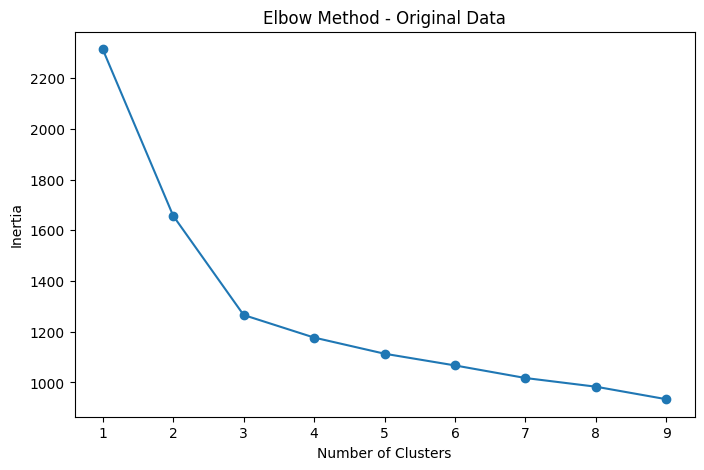

In [ ]:
# Elbow method to justify n_clusters=3
inertia = []
for k in range(1, 10):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1, 10), inertia, marker='o')
plt.title('Elbow Method - Original Data')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.show()

**Task 4: Clustering with PCA Data**

In [ ]:
##applying kmeans
kmeans_pca = KMeans(
    n_clusters=3,
    random_state=42
)

pca_clusters = kmeans_pca.fit_predict(X_pca)

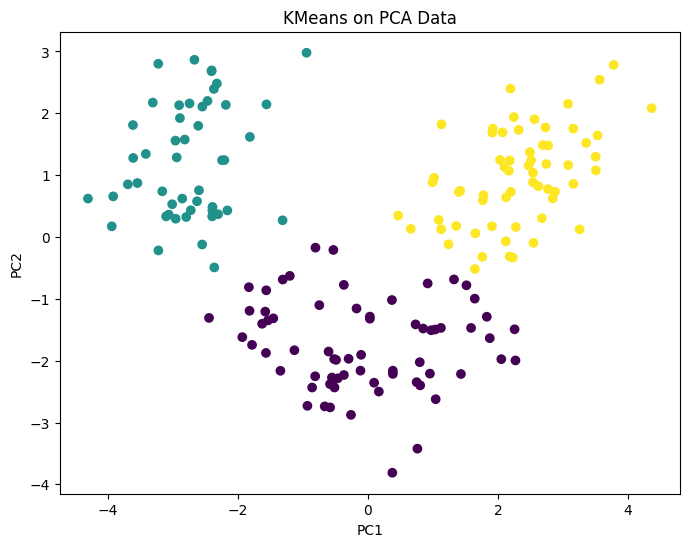

In [ ]:
#visualization
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=pca_clusters,
    cmap="viridis"
)

plt.title("KMeans on PCA Data")

plt.xlabel("PC1")

plt.ylabel("PC2")

plt.show()

In [ ]:
#evaluation
print(
    "Silhouette Score:",
    silhouette_score(
        X_pca,
        pca_clusters
    )
)

Silhouette Score: 0.5613222019327238


In [ ]:
print(
    "Davies Bouldin Index:",
    davies_bouldin_score(
        X_pca,
        pca_clusters
    )
)

Davies Bouldin Index: 0.5983440957250455


**Task 5: Comparison and Analysis**

In [ ]:
comparison = pd.DataFrame({

    "Dataset":[
        "Original",
        "PCA"
    ],

    "Silhouette Score":[
        silhouette_score(
            X_scaled,
            original_clusters
        ),

        silhouette_score(
            X_pca,
            pca_clusters
        )
    ],

    "Davies Bouldin":[
        davies_bouldin_score(
            X_scaled,
            original_clusters
        ),

        davies_bouldin_score(
            X_pca,
            pca_clusters
        )
    ]
})

comparison

,Dataset,Silhouette Score,Davies Bouldin
0,Original,0.285463,1.381606
1,PCA,0.561322,0.598344


**Humanized Analysis**

Compare the Silhouette Score and Davies–Bouldin Index of both models. A higher Silhouette Score and a lower Davies–Bouldin Index indicate better clustering performance. PCA may improve clustering by reducing noise and redundancy while preserving most of the important information.

**Task 6: Conclusion and Insights**

**Conclusion**

PCA successfully reduced the dimensionality of the wine dataset while preserving most of the important information. Clustering was performed on both the original and PCA-transformed data. Comparing the evaluation metrics helped determine whether dimensionality reduction improved clustering performance.

**Practical Implications**

PCA is useful when datasets contain many correlated features or high-dimensional data. Clustering helps identify similar groups within the data, making it easier to discover hidden patterns and support data-driven decision-making.

**Recommendations**

Use PCA before clustering when working with datasets that have many features or multicollinearity. For datasets with fewer features and clear cluster separation, clustering on the original data may also provide good results.